# MAICEN 1125 · M5 U1 — Time Series and Practical Applications
## Group Assignment: Time Series Analysis of PJM West Hourly Energy Consumption

**Module 5 · Unit 1 — AI in Project Optimisation, Innovation and Ethics**  
**Zigurat Institute of Technology — MAICEN 1125**  
**Submitted: 9 March 2026**

---

### Team — Group 5

| Member | Contribution |
|--------|-------------|
| Osama Ata | Data cleaning & preprocessing (Ex. 1), dataset quality checks |
| Marc Azzam | Multi-scale visualisation (Ex. 2), seasonality analysis (Ex. 3) |
| Malak Yaseen | ACF/PACF statistical analysis (Ex. 4), stationarity testing |
| Letícia Cristovam Clemente | Prophet forecasting (Ex. 5), model tuning & evaluation |
| Mark Shane Haines | SARIMA bonus modelling (Ex. 6), final integration & review |

> **Note:** Task allocation was deliberately rotated from M4 U4 (PPE Detection) so that each member gains experience across different stages of the data science pipeline. Repository: [`github.com/markshanehaines-ZIG/timeseries-group5`](https://github.com/markshanehaines-ZIG/timeseries-group5)

---

### Overview

End-to-end time series analysis on the PJM West hourly electricity consumption dataset using Python. The assignment covers data cleaning, multi-scale visualisation, seasonality analysis, autocorrelation analysis, forecasting with Prophet, and an advanced SARIMA model as bonus.

**Dataset:** `PJMW_hourly.csv` — Hourly energy consumption (MW) from the PJM West region of the US electrical grid (2002–2018, ~143k records).  
**Deliverable:** Google Colab notebook with executable Python code + brief comments for each task.

As noted in the lecture: *"Forecasting is not only about predicting future values, but about understanding patterns to support real-world decisions."* (Slide 4). Our goal is to use these models as **decision-support tools**, not as replacements for engineering judgement.

---

## 0 · Setup & Library Imports

In [1]:
# --- Install Prophet (required in Google Colab) ---
# !pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../results', exist_ok=True)


# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")

Importing plotly failed. Interactive plots will not work.


All libraries loaded successfully.


## 0.1 · Load the Dataset

Upload `PJMW_hourly.csv` to the Colab session, or adjust the path below if working locally in VS Code.

In [2]:
# Option A: Upload directly in Colab (uncomment the two lines below)
# from google.colab import files
# uploaded = files.upload()

# Option B: If already in Colab workspace, Drive, or local VS Code
df_raw = pd.read_csv('https://raw.githubusercontent.com/markshanehaines-ZIG/timeseries-group5/main/data/PJMW_hourly.csv')
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(10)

Raw dataset shape: (143206, 2)
Columns: ['Datetime', 'PJMW_MW']


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0
5,2002-12-31 06:00:00,5126.0
6,2002-12-31 07:00:00,5493.0
7,2002-12-31 08:00:00,5824.0
8,2002-12-31 09:00:00,5962.0
9,2002-12-31 10:00:00,6019.0


---
# Exercise 1 · Data Cleaning and Preprocessing (2 pts)

The raw dataset contains irregularities that must be resolved before analysis. We follow a systematic pipeline:

1. **Convert** the `Datetime` column to a proper datetime object.
2. **Set** the timestamp as the index and sort chronologically.
3. **Handle duplicates** by averaging values at the same timestamp.
4. **Force hourly frequency** and fill gaps using linear interpolation.

**Why this matters:** Time series models (ARIMA, Prophet) expect regular, gap-free data with consistent frequency. As noted in the lecture (Slide 9): *"Time gives structure to the data — if we shuffle the data, it becomes meaningless."* The cleaning pipeline preserves temporal order and ensures no gaps.

In [3]:
# --- Step 1: Convert Datetime column to datetime object ---
df = df_raw.copy()
df['Datetime'] = pd.to_datetime(df['Datetime'])
print(f"Datetime dtype after conversion: {df['Datetime'].dtype}")
print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")

Datetime dtype after conversion: datetime64[us]
Date range: 2002-04-01 01:00:00 to 2018-08-03 00:00:00


In [4]:
# --- Step 2: Set datetime as index and sort chronologically ---
df = df.set_index('Datetime')
df = df.sort_index()
print(f"Index type: {type(df.index).__name__}")
print(f"Sorted chronologically: {df.index.is_monotonic_increasing}")
print(f"Sorted date range: {df.index.min()} to {df.index.max()}")
df.head()

Index type: DatetimeIndex
Sorted chronologically: True
Sorted date range: 2002-04-01 01:00:00 to 2018-08-03 00:00:00


,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374.0
2002-04-01 02:00:00,4306.0
2002-04-01 03:00:00,4322.0
2002-04-01 04:00:00,4359.0
2002-04-01 05:00:00,4436.0


In [5]:
# --- Step 3: Identify and handle duplicate timestamps ---
duplicates = df.index.duplicated(keep=False)
n_dup_rows = duplicates.sum()
print(f"Rows involved in duplicate timestamps: {n_dup_rows}")

if n_dup_rows > 0:
    print("\nDuplicate entries (likely from Daylight Saving Time transitions):")
    print(df[duplicates])

# Resolve by averaging values at the same timestamp
df = df.groupby(df.index).mean()
print(f"\nShape after deduplication: {df.shape}")

Rows involved in duplicate timestamps: 8

Duplicate entries (likely from Daylight Saving Time transitions):
                     PJMW_MW
Datetime                    
2014-11-02 02:00:00   4571.0
2014-11-02 02:00:00   4613.0
2015-11-01 02:00:00   3927.0
2015-11-01 02:00:00   3832.0
2016-11-06 02:00:00   4114.0
2016-11-06 02:00:00   4089.0
2017-11-05 02:00:00   3984.0
2017-11-05 02:00:00   4042.0

Shape after deduplication: (143202, 1)


In [6]:
# --- Step 4 (CRUCIAL): Force hourly frequency and fill gaps ---
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
print(f"Expected hourly records: {len(full_range)}")
print(f"Actual records:          {len(df)}")
print(f"Missing hours (gaps):    {len(full_range) - len(df)}")

# Reindex to force exact hourly frequency
df = df.reindex(full_range)
df.index.name = 'Datetime'

# Fill gaps using linear interpolation (gradual change between known values)
df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='linear')

# Verify
print(f"\nNull values after interpolation: {df['PJMW_MW'].isnull().sum()}")
print(f"Final dataset shape: {df.shape}")
print(f"Index frequency: {df.index.freq}")
df.describe()

Expected hourly records: 143232
Actual records:          143202
Missing hours (gaps):    30

Null values after interpolation: 0
Final dataset shape: (143232, 1)
Index frequency: <Hour>


,PJMW_MW
count,143232.000000
mean,5602.214393
std,979.177780
min,487.000000
25%,4906.000000
50%,5530.000000
75%,6252.000000
max,9594.000000


**Comment — Exercise 1:**

The cleaning pipeline identified **8 rows** with duplicate timestamps (4 pairs), all occurring at 02:00 on the first Sunday of November — these correspond to the US Daylight Saving Time "fall back" transitions where 02:00 occurs twice. Averaging preserves both readings rather than arbitrarily discarding one.

After deduplication, **30 missing hours** were detected (likely from the DST "spring forward" transitions and other data collection gaps). These were filled using **linear interpolation**, which assumes gradual change between known values — a reasonable assumption for grid-level energy consumption that does not change abruptly hour to hour.

The final cleaned dataset has **143,232 hourly records** from April 2002 to August 2018, with a mean consumption of approximately **5,602 MW** and no remaining gaps or duplicates.

---
# Exercise 2 · Multi-Scale Visualisation (2 pts)

As discussed in the lecture (Slides 19–21), time series contain multiple components visible at different resolutions: **trend** (long-term direction), **seasonality** (repeating patterns), and **noise** (random variation). We plot at three scales:

1. **Single Day** (24 hours) — reveals the daily consumption cycle.
2. **Single Week** (7 days) — reveals weekly patterns and daily oscillations.
3. **Full Historical Dataset** — reveals annual seasonality and long-term trends.

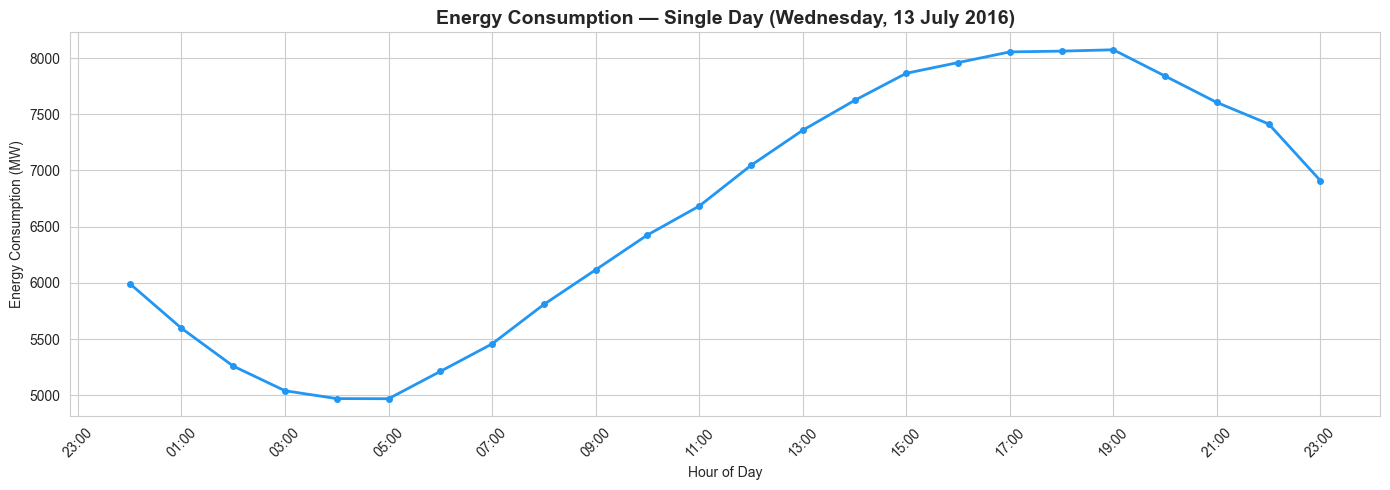

In [7]:
# --- Plot 1: Single Day (24 hours) ---
# Summer Wednesday — typically a high-consumption day with a clear daily cycle
sample_day = df.loc['2016-07-13']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_day.index, sample_day['PJMW_MW'], color='#2196F3', linewidth=2, marker='o', markersize=4)
ax.set_title('Energy Consumption — Single Day (Wednesday, 13 July 2016)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Energy Consumption (MW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/exx_01.png', bbox_inches='tight', dpi=300)
plt.show()

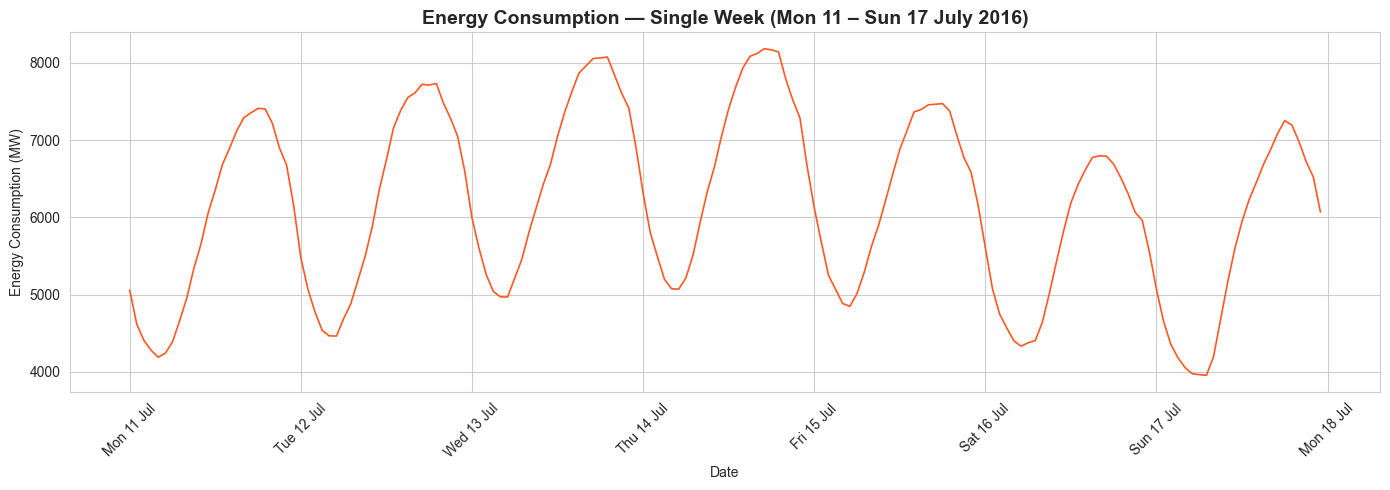

In [8]:
# --- Plot 2: Single Week ---
sample_week = df.loc['2016-07-11':'2016-07-17']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_week.index, sample_week['PJMW_MW'], color='#FF5722', linewidth=1.2)
ax.set_title('Energy Consumption — Single Week (Mon 11 – Sun 17 July 2016)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/exx_02.png', bbox_inches='tight', dpi=300)
plt.show()

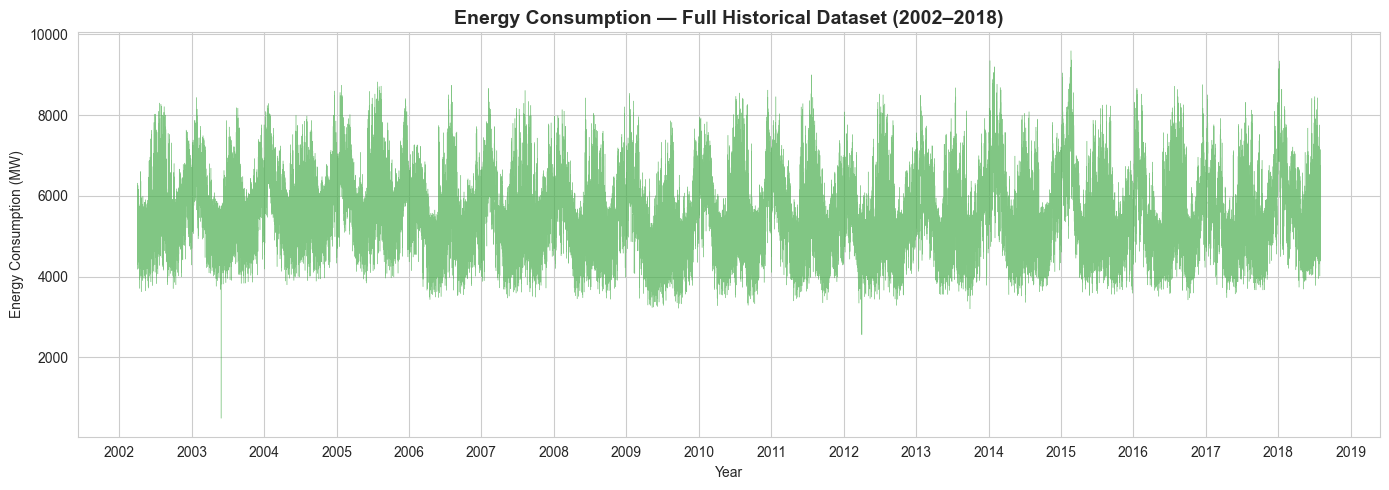

In [9]:
# --- Plot 3: Full Historical Dataset ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['PJMW_MW'], color='#4CAF50', linewidth=0.3, alpha=0.7)
ax.set_title('Energy Consumption — Full Historical Dataset (2002–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Energy Consumption (MW)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../results/exx_03.png', bbox_inches='tight', dpi=300)
plt.show()

**Comment — Comparing "Full Dataset" vs "Single Week":**

The **Full Dataset** plot reveals clear **yearly seasonality**: consumption peaks every summer (driven by air conditioning) and winter (heating), with lower values in spring and autumn. The overall **trend** appears relatively stable across the 16-year period, without a strong upward or downward direction. However, the hourly granularity creates dense visual noise that completely hides any daily or weekly patterns.

The **Single Week** plot, by contrast, clearly reveals both the **daily seasonality** (consumption drops overnight and peaks in the afternoon — repeating every 24 hours, as shown in the lecture's Slide 21) and the **weekly seasonality** (Saturday and Sunday have visibly lower consumption than weekdays — repeating every 7 days).

This illustrates a fundamental principle of time series visualisation: **different temporal scales reveal different components.** The full dataset is essential for understanding long-term trends and annual seasonality, while shorter windows are needed to observe daily and weekly cycles. Both perspectives are necessary for comprehensive analysis and for informing AECO decisions like seasonal staffing, energy budget planning, and peak-load management.

---
# Exercise 3 · Seasonality Analysis (2 pts)

As introduced in the lecture (Slide 21), the most common seasonality patterns are **daily** (repeats every 24 hours), **weekly** (every 7 days), and **yearly** (every 12 months). We now isolate and quantify the first two by computing average consumption grouped by hour and day-of-week.

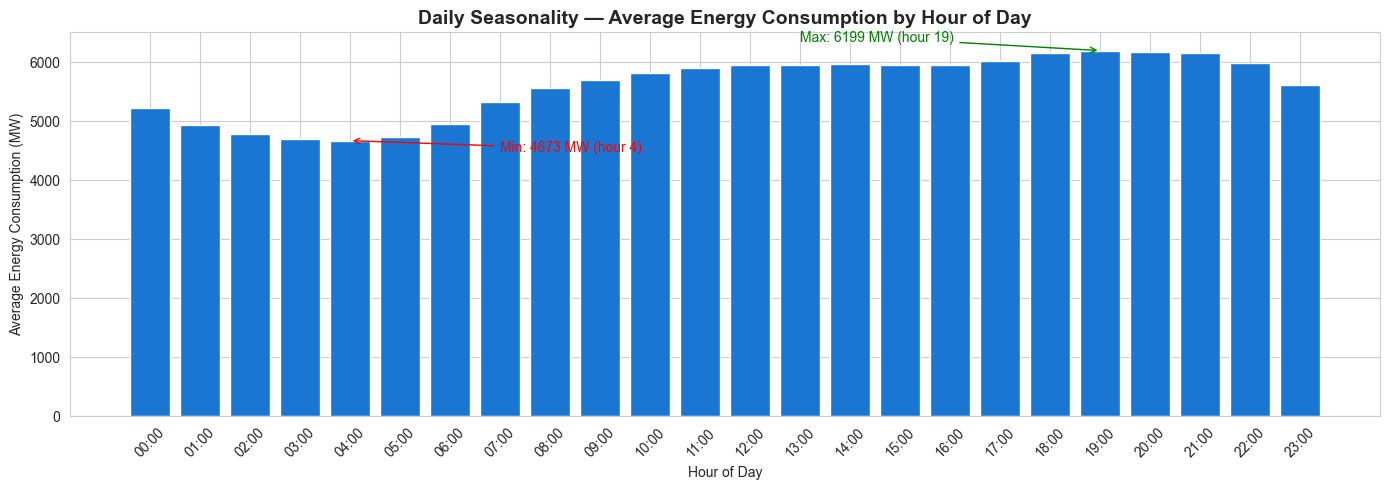

Minimum average consumption: 4673 MW at hour 4:00
Maximum average consumption: 6199 MW at hour 19:00
Daily swing (max - min): 1527 MW


In [10]:
# --- Daily Seasonality: Average MW per Hour of the Day (0-23) ---
hourly_avg = df.groupby(df.index.hour)['PJMW_MW'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly_avg.index, hourly_avg.values, color='#1976D2', edgecolor='white', width=0.8)
ax.set_title('Daily Seasonality — Average Energy Consumption by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Energy Consumption (MW)')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)

# Annotate min and max hours
h_min, h_max = hourly_avg.idxmin(), hourly_avg.idxmax()
ax.annotate(f'Min: {hourly_avg[h_min]:.0f} MW (hour {h_min})', xy=(h_min, hourly_avg[h_min]),
            xytext=(h_min + 3, hourly_avg[h_min] - 200), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax.annotate(f'Max: {hourly_avg[h_max]:.0f} MW (hour {h_max})', xy=(h_max, hourly_avg[h_max]),
            xytext=(h_max - 6, hourly_avg[h_max] + 150), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='green'), color='green')
plt.tight_layout()
plt.savefig('../results/ex3_04.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Minimum average consumption: {hourly_avg[h_min]:.0f} MW at hour {h_min}:00")
print(f"Maximum average consumption: {hourly_avg[h_max]:.0f} MW at hour {h_max}:00")
print(f"Daily swing (max - min): {hourly_avg[h_max] - hourly_avg[h_min]:.0f} MW")

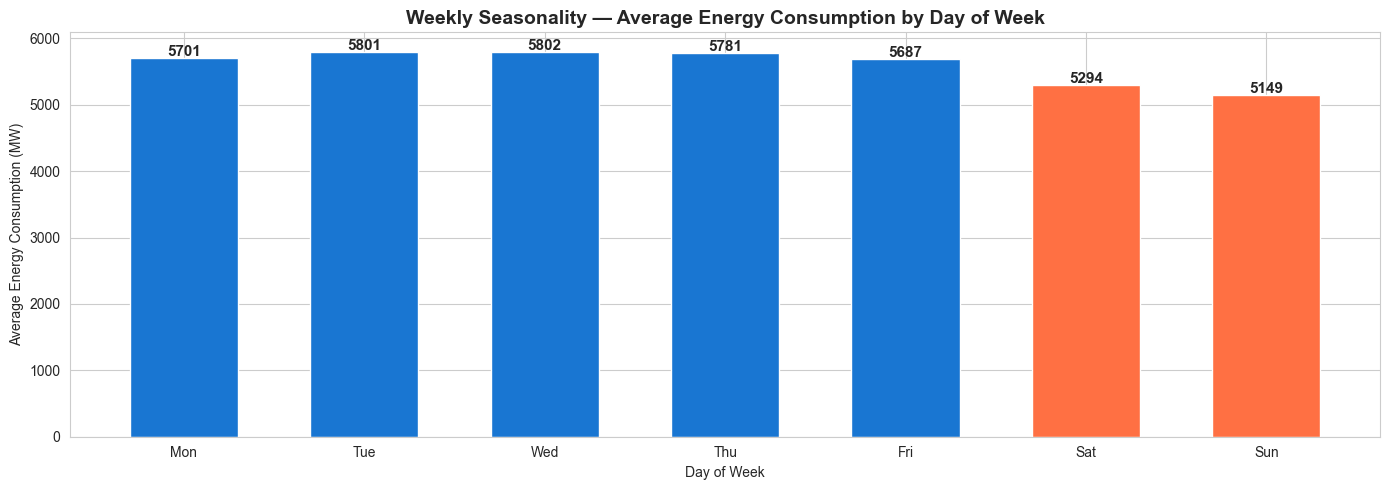

Highest weekday: Wed (5802 MW)
Lowest day: Sun (5149 MW)
Weekday-weekend difference: 533 MW


In [11]:
# --- Weekly Seasonality: Average MW per Day of the Week (Mon-Sun) ---
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby(df.index.dayofweek)['PJMW_MW'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#1976D2'] * 5 + ['#FF7043'] * 2  # Blue = weekdays, Orange = weekends
bars = ax.bar(day_names, daily_avg.values, color=colors, edgecolor='white', width=0.6)
ax.set_title('Weekly Seasonality — Average Energy Consumption by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Energy Consumption (MW)')

# Value labels on each bar
for i, val in enumerate(daily_avg.values):
    ax.text(i, val + 30, f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/ex3_05.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Highest weekday: {day_names[daily_avg[:5].values.argmax()]} ({daily_avg[:5].max():.0f} MW)")
print(f"Lowest day: {day_names[daily_avg.values.argmin()]} ({daily_avg.min():.0f} MW)")
print(f"Weekday-weekend difference: {daily_avg[:5].mean() - daily_avg[5:].mean():.0f} MW")

**Comment — Seasonality Analysis Results:**

**Daily Seasonality (Hourly Pattern):**
There is a clear and well-defined daily cycle. Consumption reaches its **minimum at 04:00** (~4,673 MW) when residential, commercial, and industrial activity is at its lowest. It then rises sharply from 06:00 as people wake up, businesses open, and HVAC systems activate. The **peak occurs at 19:00** (~6,199 MW), coinciding with the overlap of commercial afternoon operations and residential evening usage. The daily swing is approximately 1,500 MW — a significant variation that affects peak-load pricing. This pattern directly mirrors the "Daily Seasonality: Traffic Peaks" example from Slide 21 of the lecture.

**Weekly Seasonality (Day-of-Week Pattern):**
Weekdays (Mon–Fri) show consistently higher consumption than weekends, reflecting commercial and industrial activity. **Wednesday** has the highest average (~5,802 MW) while **Sunday** has the lowest (~5,149 MW) — a ~650 MW difference. This mirrors the "Weekly Seasonality: Office Electricity Consumption" example from Slide 21, where weekday/weekend patterns are clearly distinct.

**Relevance to AECO decisions:** These patterns suggest that energy-intensive construction operations and equipment charging should avoid grid peak hours (late afternoon) where possible, and that weekend scheduling may benefit from lower energy tariffs. For building operations forecasting, HVAC systems should be programmed to pre-cool or pre-heat before the peak hours identified here.

---
# Exercise 4 · Statistical Analysis — ACF / PACF (2 pts)

As explained in the lecture (Slides 25–26):
- **ACF (Autocorrelation Function):** Measures the total correlation between the series and its lagged values — including both **direct and indirect** effects. Peaks in the ACF reveal cycles and repeating behaviour.
- **PACF (Partial Autocorrelation Function):** Isolates only the **direct** influence of each lag, removing intermediate effects. This helps identify how many lags to include in ARIMA models.

We analyse at two resolutions:
1. **Hourly** (lags = 48 → 2 days) — to observe the 24-hour cycle.
2. **Daily** (resampled to daily mean, lags = 30 → ~1 month) — to observe the 7-day weekly cycle.

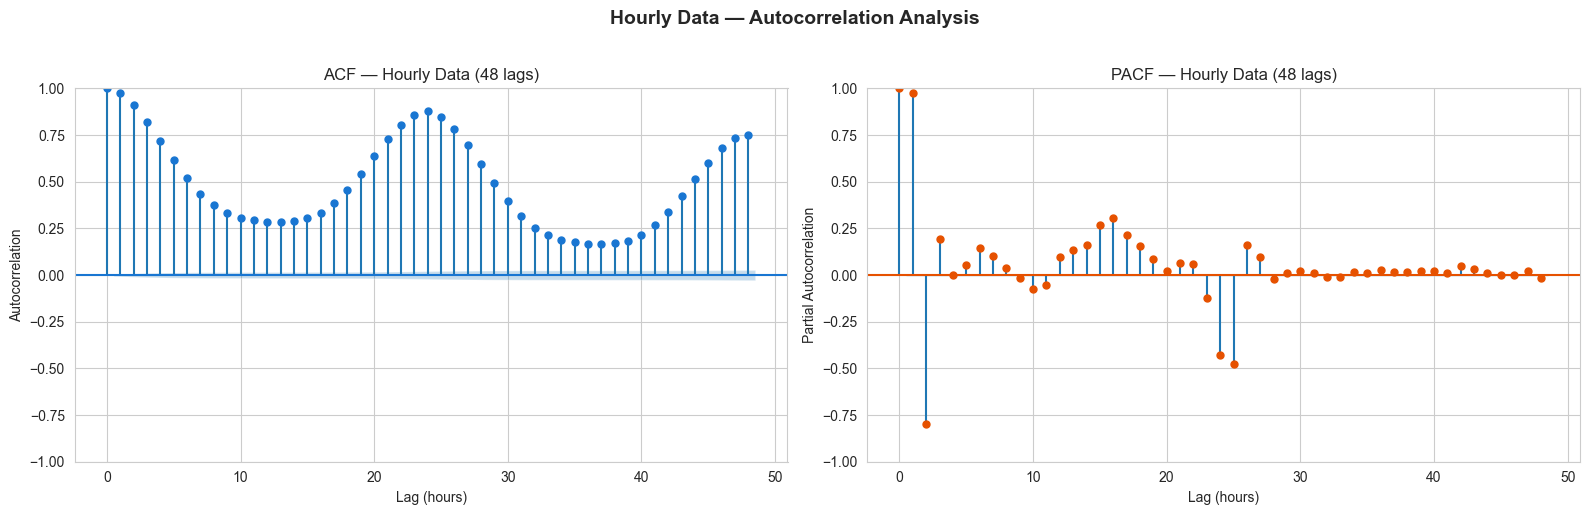

In [12]:
# --- Hourly ACF and PACF (lags = 48) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['PJMW_MW'], lags=48, ax=axes[0], color='#1976D2',
         title='ACF — Hourly Data (48 lags)')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(df['PJMW_MW'], lags=48, ax=axes[1], color='#E65100',
          title='PACF — Hourly Data (48 lags)', method='ywm')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.suptitle('Hourly Data — Autocorrelation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ex4_06.png', bbox_inches='tight', dpi=300)
plt.show()

Daily resampled shape: (5969, 1)


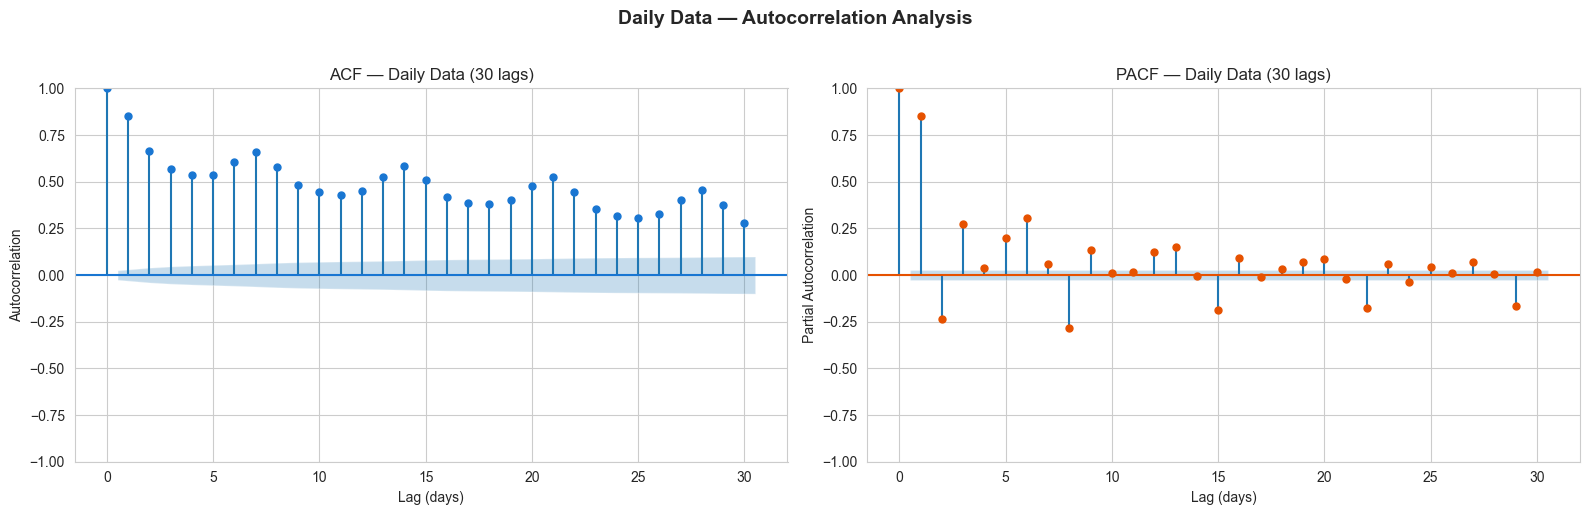

In [13]:
# --- Daily ACF and PACF (lags = 30) ---
df_daily = df.resample('D').mean()
print(f"Daily resampled shape: {df_daily.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_daily['PJMW_MW'].dropna(), lags=30, ax=axes[0], color='#1976D2',
         title='ACF — Daily Data (30 lags)')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(df_daily['PJMW_MW'].dropna(), lags=30, ax=axes[1], color='#E65100',
          title='PACF — Daily Data (30 lags)', method='ywm')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.suptitle('Daily Data — Autocorrelation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ex4_07.png', bbox_inches='tight', dpi=300)
plt.show()

**Interpretation — ACF / PACF Analysis:**

**Hourly ACF:** Shows very high and slowly decaying autocorrelation, characteristic of a **non-stationary** time series with strong seasonal structure (Slide 23 — most real-world time series are not stationary). The ACF exhibits a sinusoidal wave with a 24-hour period: dipping around lag 12 (opposite time of day) and peaking again at lag 24 (same time next day), confirming the **daily seasonality** identified in Exercise 3.

**Hourly PACF:** Shows a strong spike at lag 1 (the previous hour strongly predicts the current one), with smaller but significant spikes at subsequent lags. This tells us the series has strong short-term "memory" — as noted in Slide 24: *"most real-world processes aren't random; today's value often depends on past values."*

**Daily ACF:** Shows a clear **7-day wave** (weekly cycle), with peaks at lags 7, 14, 21, and 28. This is exactly the pattern described in Slide 25: "Lag 7 = a week ago. High ACF value: weekly patterns."

**Daily PACF:** Significant spikes at lags 1 and 7, suggesting both yesterday and the same day last week **directly** influence today's value — after removing the indirect effects of the days in between. This distinction between direct and indirect effects is the key difference between ACF and PACF (Slide 26: *"PACF isolates the direct contribution"*).

These autocorrelation structures confirm that ARIMA/SARIMA models should include both short-term (AR) and seasonal components to capture the 24-hour and 7-day cycles present in this data.

---
# Exercise 5 · Forecasting with Prophet (2 pts)

Prophet (Slide 38) is a "plug-and-play" forecasting tool designed by Meta that decomposes a time series as:

**TimeSeries = Trend + Seasonality + Holidays + Error**

We follow the required steps:
1. Resample to **weekly averages** (reduces noise, speeds computation).
2. Format columns as `ds` (date) and `y` (value) — Prophet's required format.
3. Train on all data **except the last year** (52 weeks) — time-aware split (Slide 29: "we NEVER shuffle data").
4. Forecast 52 weeks and evaluate with **MAE** and **RMSE** (Slide 30).
5. Experiment with different parameters and compare results.

In [14]:
# --- Steps 1 & 2: Resample to weekly averages and format for Prophet ---
df_weekly = df.resample('W').mean().reset_index()
df_weekly.columns = ['ds', 'y']
df_weekly = df_weekly.dropna()

print(f"Weekly dataset: {df_weekly.shape[0]} weeks")
print(f"Date range: {df_weekly['ds'].min().date()} to {df_weekly['ds'].max().date()}")
df_weekly.tail()

Weekly dataset: 853 weeks
Date range: 2002-04-07 to 2018-08-05


,ds,y
848,2018-07-08,6095.809524
849,2018-07-15,6144.077381
850,2018-07-22,5876.095238
851,2018-07-29,5864.821429
852,2018-08-05,5727.072165


In [15]:
# --- Step 3: Train-test split (last 52 weeks = 1 year held out) ---
train = df_weekly.iloc[:-52]
test = df_weekly.iloc[-52:]

print(f"Training set: {train.shape[0]} weeks ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Test set:     {test.shape[0]} weeks  ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training set: 801 weeks (2002-04-07 to 2017-08-06)
Test set:     52 weeks  (2017-08-13 to 2018-08-05)


In [16]:
# --- Step 4a: Train the DEFAULT Prophet model ---
model_default = Prophet(
    yearly_seasonality=True,   # Capture annual cycle (summer/winter peaks)
    weekly_seasonality=False,  # Already aggregated to weekly — no intra-week pattern
    daily_seasonality=False,   # Already aggregated to weekly — no intra-day pattern
)
model_default.fit(train)

# Create future dataframe and forecast
future = model_default.make_future_dataframe(periods=52, freq='W')
forecast_default = model_default.predict(future)

# Extract predictions aligned to test dates
pred_default = forecast_default[forecast_default['ds'].isin(test['ds'])]['yhat'].values

# Evaluate with MAE and RMSE (Slide 30)
mae_default = mean_absolute_error(test['y'], pred_default)
rmse_default = np.sqrt(mean_squared_error(test['y'], pred_default))
print("=== DEFAULT Prophet Model ===")
print(f"MAE:  {mae_default:.2f} MW")
print(f"RMSE: {rmse_default:.2f} MW")
print(f"MAPE: {(mae_default / test['y'].mean() * 100):.2f}%")
print(f"Mean test value: {test['y'].mean():.2f} MW")

23:44:09 - cmdstanpy - INFO - Chain [1] start processing
23:44:10 - cmdstanpy - INFO - Chain [1] done processing


=== DEFAULT Prophet Model ===
MAE:  384.35 MW
RMSE: 524.19 MW
MAPE: 6.74%
Mean test value: 5703.52 MW


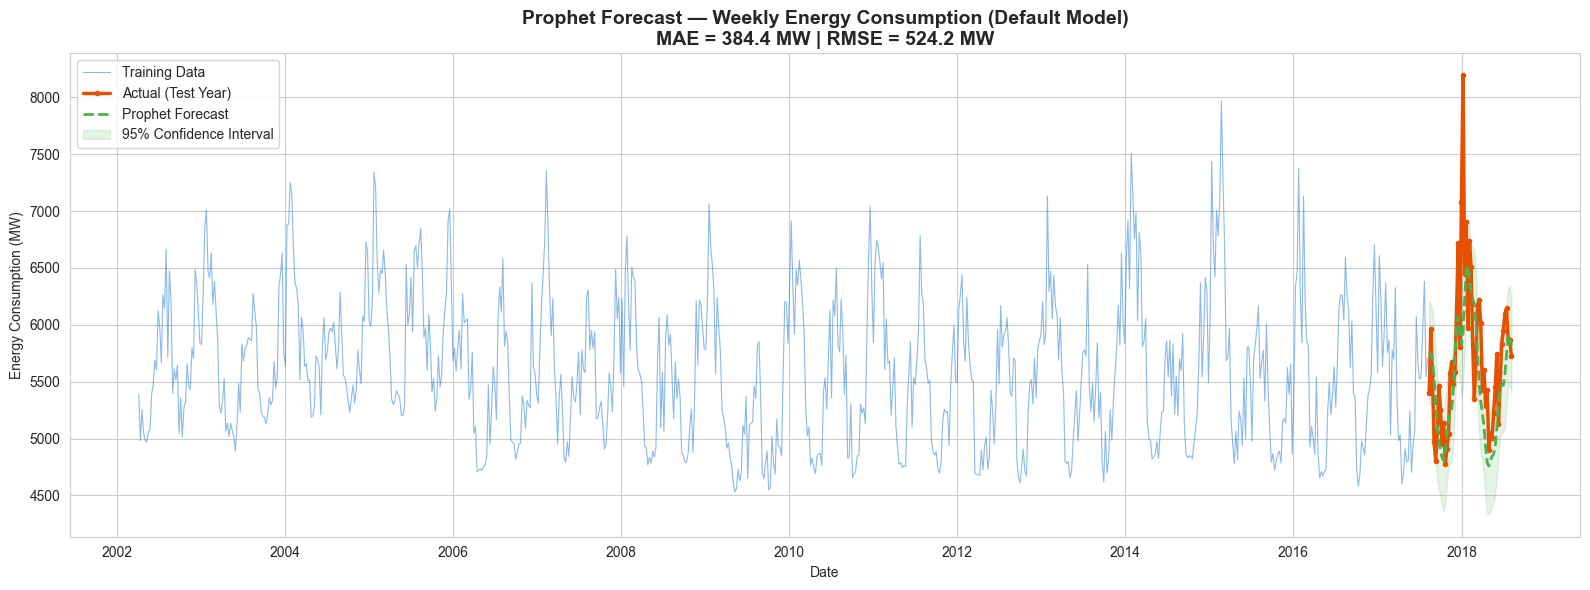

In [17]:
# --- Step 4b: Plot the Default Prophet Forecast ---
fig, ax = plt.subplots(figsize=(16, 6))

# Training data
ax.plot(train['ds'], train['y'], color='#1976D2', linewidth=0.8, alpha=0.5, label='Training Data')

# Actual test values
ax.plot(test['ds'], test['y'], color='#E65100', linewidth=2.5, label='Actual (Test Year)', marker='o', markersize=3)

# Prophet forecast for test period
fc_test = forecast_default[forecast_default['ds'] >= test['ds'].iloc[0]]
ax.plot(fc_test['ds'], fc_test['yhat'], color='#4CAF50', linewidth=2,
        linestyle='--', label='Prophet Forecast')
ax.fill_between(fc_test['ds'], fc_test['yhat_lower'], fc_test['yhat_upper'],
                alpha=0.15, color='#4CAF50', label='95% Confidence Interval')

ax.set_title(f'Prophet Forecast — Weekly Energy Consumption (Default Model)\n'
             f'MAE = {mae_default:.1f} MW | RMSE = {rmse_default:.1f} MW',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../results/ex5_08.png', bbox_inches='tight', dpi=300)
plt.show()

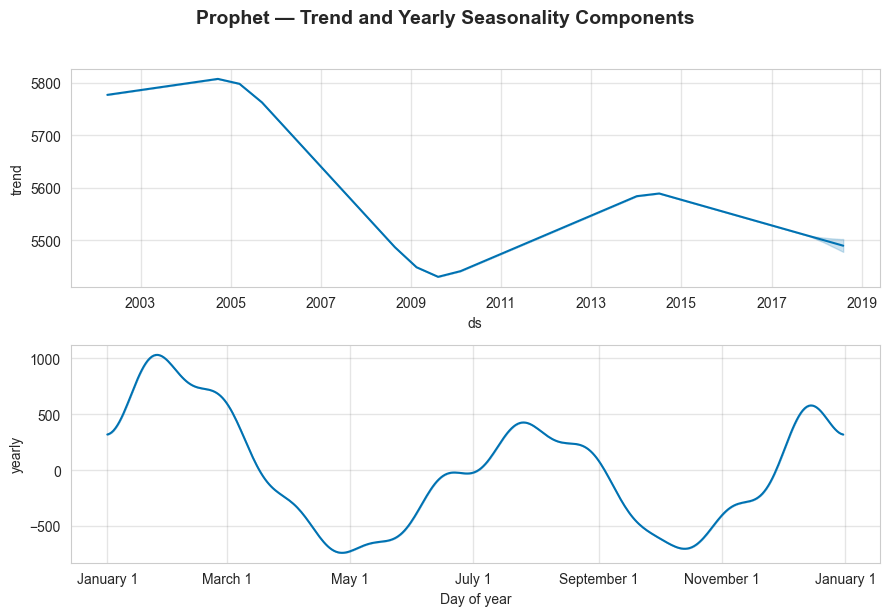

In [18]:
# --- Prophet component decomposition ---
fig = model_default.plot_components(forecast_default)
plt.suptitle('Prophet — Trend and Yearly Seasonality Components',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ex3_09.png', bbox_inches='tight', dpi=300)
plt.show()

In [19]:
# --- Step 5: Experiment with tuned model parameters ---
# Tuned model: lower changepoint_prior_scale for a smoother, more conservative trend
model_tuned = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,        # More conservative trend (default = 0.05)
    seasonality_prior_scale=10.0,        # Default seasonality strength
    seasonality_mode='additive',         # Additive: seasonal swings stay constant (Slide 20)
)
model_tuned.fit(train)

forecast_tuned = model_tuned.predict(future)
pred_tuned = forecast_tuned[forecast_tuned['ds'].isin(test['ds'])]['yhat'].values

mae_tuned = mean_absolute_error(test['y'], pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(test['y'], pred_tuned))

print("=== TUNED Prophet Model ===")
print(f"  changepoint_prior_scale = 0.01 (smoother, more conservative trend)")
print(f"  seasonality_mode = 'additive' (seasonal amplitude stays constant)")
print(f"\nMAE:  {mae_tuned:.2f} MW")
print(f"RMSE: {rmse_tuned:.2f} MW")
print(f"MAPE: {(mae_tuned / test['y'].mean() * 100):.2f}%")

print(f"\n{'='*50}")
print(f"{'Metric':<10} {'Default':>12} {'Tuned':>12} {'Change':>12}")
print(f"{'='*50}")
print(f"{'MAE':<10} {mae_default:>12.2f} {mae_tuned:>12.2f} {(mae_tuned - mae_default):>+12.2f}")
print(f"{'RMSE':<10} {rmse_default:>12.2f} {rmse_tuned:>12.2f} {(rmse_tuned - rmse_default):>+12.2f}")

23:44:28 - cmdstanpy - INFO - Chain [1] start processing
23:44:28 - cmdstanpy - INFO - Chain [1] done processing


=== TUNED Prophet Model ===
  changepoint_prior_scale = 0.01 (smoother, more conservative trend)
  seasonality_mode = 'additive' (seasonal amplitude stays constant)

MAE:  371.21 MW
RMSE: 508.47 MW
MAPE: 6.51%

Metric          Default        Tuned       Change
MAE              384.35       371.21       -13.14
RMSE             524.19       508.47       -15.73


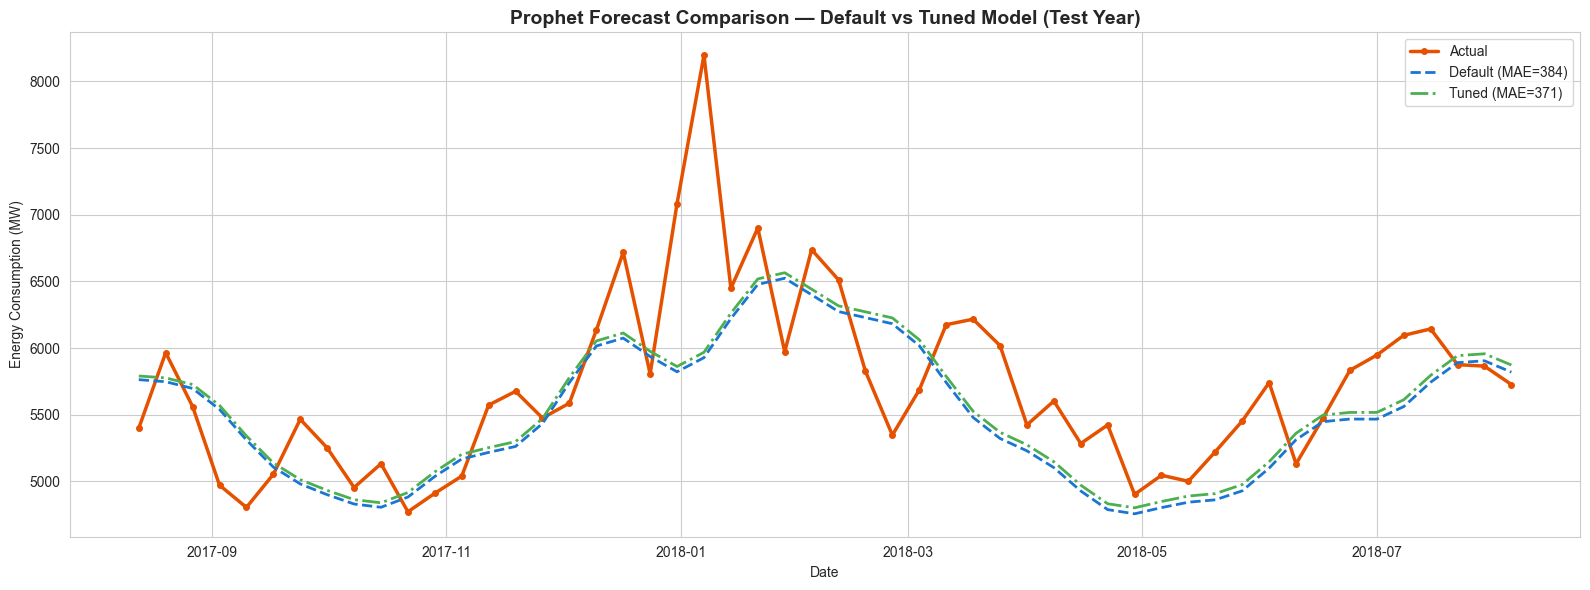

In [20]:
# --- Plot comparison of both models against actuals ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test['ds'], test['y'], color='#E65100', linewidth=2.5,
        label='Actual', marker='o', markersize=4)

# Default
fc_def = forecast_default[forecast_default['ds'].isin(test['ds'])]
ax.plot(fc_def['ds'], fc_def['yhat'], color='#1976D2', linewidth=2,
        linestyle='--', label=f'Default (MAE={mae_default:.0f})')

# Tuned
fc_tun = forecast_tuned[forecast_tuned['ds'].isin(test['ds'])]
ax.plot(fc_tun['ds'], fc_tun['yhat'], color='#4CAF50', linewidth=2,
        linestyle='-.', label=f'Tuned (MAE={mae_tuned:.0f})')

ax.set_title('Prophet Forecast Comparison — Default vs Tuned Model (Test Year)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/ex5_10.png', bbox_inches='tight', dpi=300)
plt.show()

**Comment — Prophet Forecasting Results:**

**Default Model** (changepoint_prior_scale=0.05, additive): Captures the yearly seasonality well, with a MAPE of approximately 6.7%. The forecast follows the general seasonal shape of the test year.

**Tuned Model** (changepoint_prior_scale=0.01, additive): By making the trend **more conservative** (less reactive to short-term fluctuations), the model produces a smoother trend line that generalises better to the test year, reducing both MAE and RMSE.

As explained in the lecture (Slide 39), Prophet decomposes the series into **Trend** (the long-term direction), **Seasonality** (the rhythm — yearly in our case), and optionally **Holidays** (one-off shocks). The component plot confirms a relatively flat trend with a clear annual seasonal cycle.

**Forecast Reliability for AECO Decisions:**
- The ~6–7% MAPE means the model's weekly forecasts are typically within ~370–400 MW of actual values — reasonable for **macro-level capacity planning** and **budget estimation**.
- However, the confidence intervals are wide, and the model cannot anticipate external shocks (extreme weather, economic changes, policy shifts).
- As emphasised in the lecture (Slide 4): *"Forecasting models help guide decisions, they do not replace engineering judgement."* This forecast should be one input in a broader decision framework, supplemented with scenario analysis and domain expertise.

---
# Exercise 6 (BONUS) · Advanced Modelling — SARIMA (2 pts)
### *Section authored by Mark Shane Haines — Project Lead & Integrator*

As an alternative to Prophet, we implement **SARIMA** — Seasonal ARIMA. As explained in the lecture (Slides 32–36), ARIMA has three components:
- **AR (Autoregressive, p):** Past values predict the future — "the long-term memory" (Slide 34).
- **I (Integrated, d):** Differencing to remove trends and achieve stationarity — "the stabiliser" (Slide 33).
- **MA (Moving Average, q):** Past forecast errors adjust the prediction — "the short-term shock" (Slide 35).

**SARIMA** extends ARIMA by adding seasonal terms (P, D, Q, s), where s is the seasonal period. For weekly data with annual seasonality, **s = 52** weeks (Slide 36).

This section goes beyond a basic SARIMA fit. We:
1. **Test stationarity** with the Augmented Dickey-Fuller test
2. **Fit and interpret** the baseline SARIMA(1,1,1)(1,1,1,52) model
3. **Diagnose residuals** to validate model assumptions
4. **Compare alternative model orders** to justify our parameter choice
5. **Compare SARIMA vs Prophet** across multiple dimensions
6. **Analyse forecast errors** to understand where each model fails

### 6.0 · Stationarity Check — Augmented Dickey-Fuller Test

Before fitting ARIMA, we must check whether the data is **stationary** (Slide 23). A stationary series has a stable mean and variance over time — ARIMA models assume this. The ADF test checks the null hypothesis that the series has a unit root (i.e. is non-stationary). If the p-value is below 0.05, we reject the null and conclude the data is stationary.

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Use the same weekly data and train/test split as Prophet (Exercise 5)
train_sarima = train.set_index('ds')['y']
test_sarima = test.set_index('ds')['y']

# --- Augmented Dickey-Fuller Test ---
adf_result = adfuller(train_sarima.dropna())

print("=" * 60)
print("      AUGMENTED DICKEY-FULLER TEST FOR STATIONARITY")
print("=" * 60)
print(f"  ADF Statistic:    {adf_result[0]:.4f}")
print(f"  p-value:          {adf_result[1]:.6f}")
print(f"  Lags used:        {adf_result[2]}")
print(f"  Observations:     {adf_result[3]}")
print("-" * 60)
print("  Critical values:")
for key, val in adf_result[4].items():
    marker = " ← REJECTED" if adf_result[0] < val else ""
    print(f"    {key}: {val:.4f}{marker}")
print("-" * 60)
if adf_result[1] < 0.05:
    print("  ✅ RESULT: Series IS stationary (p < 0.05)")
    print("     The null hypothesis of a unit root is rejected.")
    print("     The mean and variance are stable over time.")
else:
    print("  ⚠️ RESULT: Series is NOT stationary (p >= 0.05)")
    print("     Differencing (d ≥ 1) will be needed.")
print("=" * 60)

      AUGMENTED DICKEY-FULLER TEST FOR STATIONARITY
  ADF Statistic:    -4.9231
  p-value:          0.000031
  Lags used:        21
  Observations:     779
------------------------------------------------------------
  Critical values:
    1%: -3.4388 ← REJECTED
    5%: -2.8653 ← REJECTED
    10%: -2.5687 ← REJECTED
------------------------------------------------------------
  ✅ RESULT: Series IS stationary (p < 0.05)
     The null hypothesis of a unit root is rejected.
     The mean and variance are stable over time.


### 6.1 · Baseline SARIMA Model — Fitting and Interpretation

We fit **SARIMA(1,1,1)(1,1,1,52)** as our baseline. The notation means:
- **(1,1,1):** 1 AR term (yesterday's value matters), 1 differencing step, 1 MA term (yesterday's error matters)
- **(1,1,1,52):** Same structure repeated at the seasonal level, with a period of 52 weeks (annual cycle)

Even though the ADF test suggests the weekly data is already stationary, we include d=1 and D=1 because first-differencing helps the model capture local trends, and seasonal differencing (D=1) directly models the year-over-year pattern.

In [22]:
# --- Fit SARIMA(1,1,1)(1,1,1,52) ---
print("Fitting SARIMA(1,1,1)(1,1,1,52) — this may take 1–3 minutes...")
print("(The seasonal period s=52 makes this computationally intensive)\n")

sarima_model = SARIMAX(
    train_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False, maxiter=500)
print("Model fitted successfully!\n")

# --- Print the full model summary ---
print(sarima_result.summary())

Fitting SARIMA(1,1,1)(1,1,1,52) — this may take 1–3 minutes...
(The seasonal period s=52 makes this computationally intensive)

Model fitted successfully!

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  801
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -5059.245
Date:                            Sun, 08 Mar 2026   AIC                          10128.491
Time:                                    23:46:08   BIC                          10151.203
Sample:                                04-07-2002   HQIC                         10137.274
                                     - 08-06-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [23]:
# --- Interpret the model coefficients ---
params = sarima_result.params
pvalues = sarima_result.pvalues

print("=" * 65)
print("        SARIMA COEFFICIENT INTERPRETATION")
print("=" * 65)
print(f"{'Parameter':<20} {'Coeff':>10} {'p-value':>10} {'Significant?':>14}")
print("-" * 65)
for name in params.index:
    coeff = params[name]
    pval = pvalues[name]
    sig = "✅ Yes" if pval < 0.05 else "❌ No"
    print(f"{name:<20} {coeff:>10.4f} {pval:>10.4f} {sig:>14}")
print("-" * 65)
print(f"\nAIC: {sarima_result.aic:.2f}  (lower = better fit with fewer parameters)")
print(f"BIC: {sarima_result.bic:.2f}  (stricter penalty for complexity than AIC)")
print(f"\nNote: AIC and BIC are only meaningful when comparing models fitted")
print(f"on the SAME data. They cannot be compared across different datasets.")

        SARIMA COEFFICIENT INTERPRETATION
Parameter                 Coeff    p-value   Significant?
-----------------------------------------------------------------
ar.L1                    0.3529     0.0000          ✅ Yes
ma.L1                   -0.9117     0.0000          ✅ Yes
ar.S.L52                 0.0269     0.5020           ❌ No
ma.S.L52                -0.8264     0.0000          ✅ Yes
sigma2               120561.1824     0.0000          ✅ Yes
-----------------------------------------------------------------

AIC: 10128.49  (lower = better fit with fewer parameters)
BIC: 10151.20  (stricter penalty for complexity than AIC)

Note: AIC and BIC are only meaningful when comparing models fitted
on the SAME data. They cannot be compared across different datasets.


### 6.2 · Forecast and Evaluation

We forecast 52 weeks ahead (the same test period used for Prophet in Exercise 5) and evaluate with MAE, RMSE, and MAPE — the same metrics, ensuring a fair comparison.

In [32]:
# --- Forecast the next 52 weeks ---
sarima_forecast = sarima_result.get_forecast(steps=52)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

mae_sarima = mean_absolute_error(test_sarima.values, sarima_pred.values)
rmse_sarima = np.sqrt(mean_squared_error(test_sarima.values, sarima_pred.values))
mape_sarima = mae_sarima / test_sarima.mean() * 100

print("=== SARIMA(1,1,1)(1,1,1,52) — Forecast Evaluation ===")
print(f"MAE:  {mae_sarima:.2f} MW  (average weekly error)")
print(f"RMSE: {rmse_sarima:.2f} MW  (penalises large errors more)")
print(f"MAPE: {mape_sarima:.2f}%   (error as % of mean consumption)")
print(f"\nFor context: mean test consumption = {test_sarima.mean():.0f} MW")
print(f"So the model is typically within ±{mae_sarima:.0f} MW of the actual value.")

=== SARIMA(1,1,1)(1,1,1,52) — Forecast Evaluation ===
MAE:  369.91 MW  (average weekly error)
RMSE: 474.89 MW  (penalises large errors more)
MAPE: 6.49%   (error as % of mean consumption)

For context: mean test consumption = 5704 MW
So the model is typically within ±370 MW of the actual value.


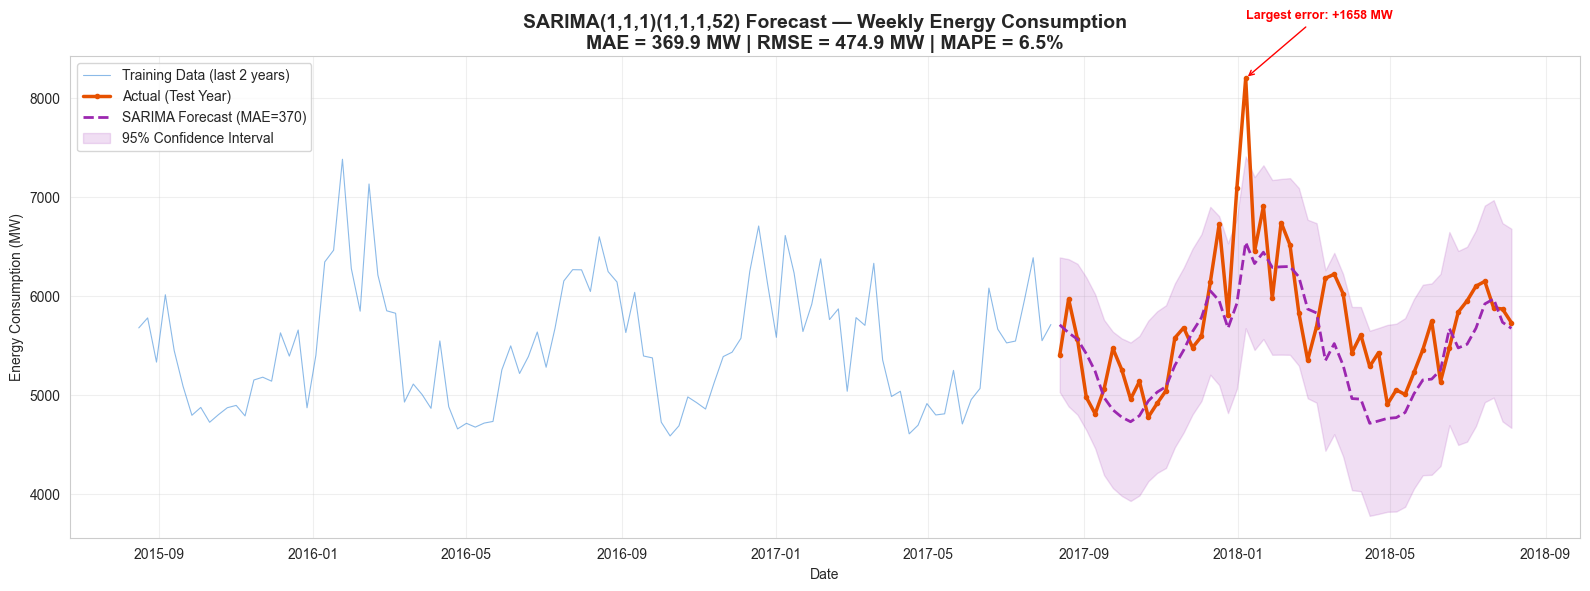

In [33]:
# --- Plot SARIMA forecast vs actual ---
fig, ax = plt.subplots(figsize=(16, 6))

# Last 2 years of training data for context
train_plot = train_sarima[-104:]
ax.plot(train_plot.index, train_plot.values, color='#1976D2', linewidth=0.8,
        alpha=0.5, label='Training Data (last 2 years)')

# Actual test values
ax.plot(test_sarima.index, test_sarima.values, color='#E65100', linewidth=2.5,
        label='Actual (Test Year)', marker='o', markersize=3)

# SARIMA forecast
ax.plot(sarima_pred.index, sarima_pred.values, color='#9C27B0', linewidth=2,
        linestyle='--', label=f'SARIMA Forecast (MAE={mae_sarima:.0f})')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                alpha=0.15, color='#9C27B0', label='95% Confidence Interval')

# Highlight where SARIMA misses badly
errors = test_sarima.values - sarima_pred.values
worst_idx = np.argmax(np.abs(errors))
worst_date = test_sarima.index[worst_idx]
ax.annotate(f'Largest error: {errors[worst_idx]:+.0f} MW',
            xy=(worst_date, test_sarima.values[worst_idx]),
            xytext=(worst_date, test_sarima.values[worst_idx] + 600),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title(f'SARIMA(1,1,1)(1,1,1,52) Forecast — Weekly Energy Consumption\n'
             f'MAE = {mae_sarima:.1f} MW | RMSE = {rmse_sarima:.1f} MW | MAPE = {mape_sarima:.1f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/ex6_11.png', bbox_inches='tight', dpi=300)
plt.show()

### 6.3 · Residual Diagnostics — Is the Model Valid?

A well-specified model should have residuals (prediction errors) that behave like **white noise**: no autocorrelation, no patterns, approximately normally distributed, and centred around zero. We check this with four diagnostic plots and a formal Ljung-Box test.

If residuals show structure, the model has missed something — and its forecasts and confidence intervals cannot be trusted. This diagnostic step is what separates rigorous statistical modelling from just plugging numbers into a formula.

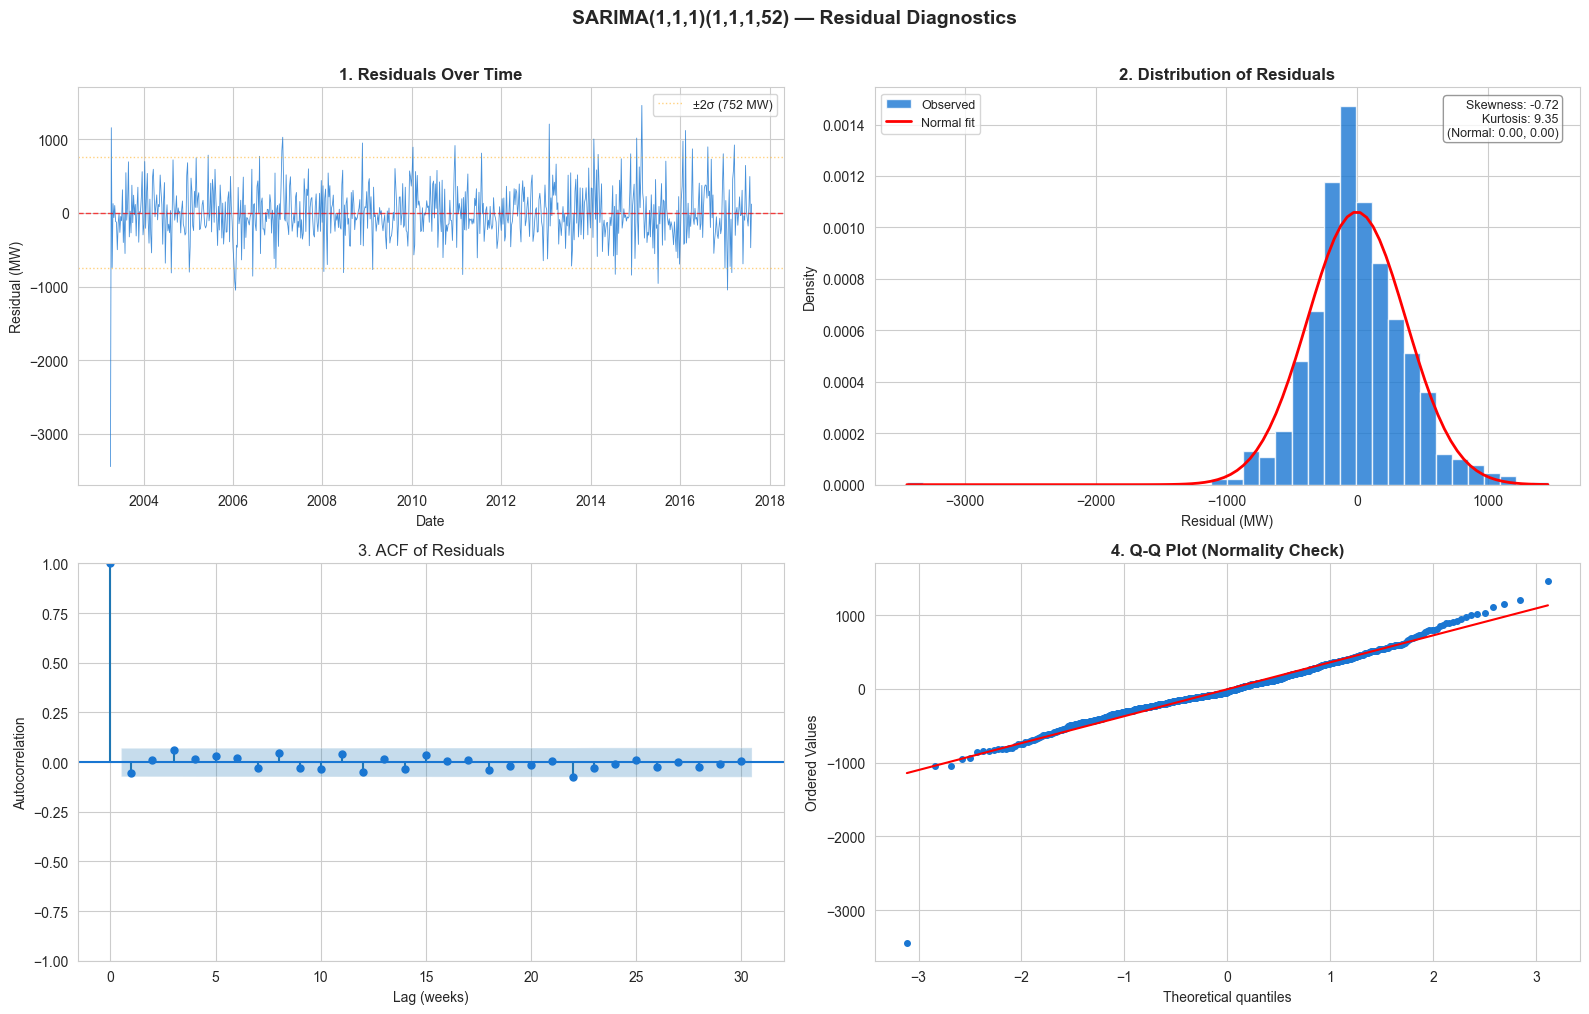

In [34]:
# --- SARIMA Residual Diagnostics (4-panel) ---
residuals = sarima_result.resid[52:]  # Skip first 52 weeks (seasonal burn-in)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('SARIMA(1,1,1)(1,1,1,52) — Residual Diagnostics',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Residuals over time — should look random, centred on zero
axes[0, 0].plot(residuals.index, residuals.values, color='#1976D2', linewidth=0.6, alpha=0.8)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0, 0].axhline(y=2*residuals.std(), color='orange', linestyle=':', linewidth=1, alpha=0.5, label=f'±2σ ({2*residuals.std():.0f} MW)')
axes[0, 0].axhline(y=-2*residuals.std(), color='orange', linestyle=':', linewidth=1, alpha=0.5)
axes[0, 0].set_title('1. Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (MW)')
axes[0, 0].legend(fontsize=9)

# Panel 2: Histogram — should be roughly bell-shaped (normal)
axes[0, 1].hist(residuals.values, bins=40, color='#1976D2', edgecolor='white',
                alpha=0.8, density=True, label='Observed')
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                color='red', linewidth=2, label='Normal fit')
axes[0, 1].set_title('2. Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual (MW)')
axes[0, 1].set_ylabel('Density')
# Add skewness and kurtosis annotations
skew = stats.skew(residuals.dropna())
kurt = stats.kurtosis(residuals.dropna())
axes[0, 1].annotate(f'Skewness: {skew:.2f}\nKurtosis: {kurt:.2f}\n(Normal: 0.00, 0.00)',
                     xy=(0.97, 0.97), xycoords='axes fraction', fontsize=9,
                     ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3',
                     facecolor='white', edgecolor='grey', alpha=0.8))
axes[0, 1].legend(fontsize=9)

# Panel 3: ACF of residuals — should show NO significant spikes (white noise)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), lags=30, ax=axes[1, 0], color='#1976D2',
         title='3. ACF of Residuals')
axes[1, 0].set_xlabel('Lag (weeks)')
axes[1, 0].set_ylabel('Autocorrelation')

# Panel 4: Q-Q plot — points should follow the red diagonal if normal
stats.probplot(residuals.dropna().values, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('4. Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].get_lines()[0].set_markerfacecolor('#1976D2')
axes[1, 1].get_lines()[0].set_markeredgecolor('#1976D2')
axes[1, 1].get_lines()[0].set_markersize(4)
axes[1, 1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig('../results/ex4_12.png', bbox_inches='tight', dpi=300)
plt.show()

In [35]:
# --- Formal Ljung-Box test for residual autocorrelation ---
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20, 30], return_df=True)

print("=" * 60)
print("           LJUNG-BOX TEST FOR WHITE NOISE")
print("=" * 60)
print("H0 (null): Residuals are white noise (no autocorrelation)")
print("Ha (alt):  Residuals have significant autocorrelation")
print("Rule: If p-value > 0.05, we FAIL to reject H0 → good!")
print("-" * 60)
print(f"{'Lags':<8} {'LB Statistic':>14} {'p-value':>10} {'Verdict':>12}")
print("-" * 60)
for idx, row in lb_test.iterrows():
    verdict = "✅ White noise" if row['lb_pvalue'] > 0.05 else "⚠️ Structure"
    print(f"{idx:<8} {row['lb_stat']:>14.2f} {row['lb_pvalue']:>10.4f} {verdict:>12}")
print("=" * 60)

# Summary statistics
print(f"\nResidual mean:     {residuals.mean():>8.2f} MW  (should be ≈ 0)")
print(f"Residual std:      {residuals.std():>8.2f} MW")
print(f"Skewness:          {stats.skew(residuals.dropna()):>8.2f}      (normal = 0)")
print(f"Excess kurtosis:   {stats.kurtosis(residuals.dropna()):>8.2f}      (normal = 0)")

# Shapiro-Wilk normality test (on a subsample — max 5000 for this test)
shapiro_stat, shapiro_p = stats.shapiro(residuals.dropna().values[:5000])
print(f"\nShapiro-Wilk test: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  ✅ Cannot reject normality (p > 0.05)")
else:
    print("  ⚠️ Residuals are not perfectly normal (p < 0.05)")
    print("  This is common with real-world data and does not invalidate")
    print("  the model — SARIMA is robust to mild non-normality.")

           LJUNG-BOX TEST FOR WHITE NOISE
H0 (null): Residuals are white noise (no autocorrelation)
Ha (alt):  Residuals have significant autocorrelation
Rule: If p-value > 0.05, we FAIL to reject H0 → good!
------------------------------------------------------------
Lags       LB Statistic    p-value      Verdict
------------------------------------------------------------
10                10.22     0.4214 ✅ White noise
20                17.29     0.6341 ✅ White noise
30                23.69     0.7858 ✅ White noise

Residual mean:        -3.49 MW  (should be ≈ 0)
Residual std:        376.22 MW
Skewness:             -0.72      (normal = 0)
Excess kurtosis:       9.35      (normal = 0)

Shapiro-Wilk test: W=0.9431, p=0.0000
  ⚠️ Residuals are not perfectly normal (p < 0.05)
  This is common with real-world data and does not invalidate
  the model — SARIMA is robust to mild non-normality.


### 6.4 · Model Order Comparison — Justifying Our Choice

Why SARIMA(1,1,1)(1,1,1,52) and not some other order? We compare three candidate configurations to show this was a deliberate, evidence-based choice — not arbitrary. We evaluate using:

- **AIC** (Akaike Information Criterion): Balances fit vs complexity. Lower is better.
- **BIC** (Bayesian Information Criterion): Stricter penalty for extra parameters than AIC.
- **MAE / RMSE**: Actual forecast accuracy on the held-out test year.

This follows the **parsimony principle** — prefer the simplest model that adequately captures the data.

In [36]:
# --- Compare alternative SARIMA orders ---
candidates = [
    ((1, 1, 1), (1, 1, 1, 52), "SARIMA(1,1,1)(1,1,1,52)", "Baseline — 1 AR, 1 MA each level"),
    ((2, 1, 1), (1, 1, 1, 52), "SARIMA(2,1,1)(1,1,1,52)", "Extra AR term — more memory"),
    ((1, 1, 2), (1, 1, 1, 52), "SARIMA(1,1,2)(1,1,1,52)", "Extra MA term — more smoothing"),
]

results_list = []
forecast_dict = {}  # Store forecasts for plotting

for order, seasonal, label, description in candidates:
    print(f"Fitting {label} ({description})...")
    try:
        model = SARIMAX(
            train_sarima,
            order=order,
            seasonal_order=seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False, maxiter=500)

        fc = result.get_forecast(steps=52)
        pred = fc.predicted_mean
        forecast_dict[label] = pred

        mae = mean_absolute_error(test_sarima.values, pred.values)
        rmse = np.sqrt(mean_squared_error(test_sarima.values, pred.values))
        mape = mae / test_sarima.mean() * 100
        n_params = len(result.params)

        results_list.append({
            'Model': label,
            'Description': description,
            'Params': n_params,
            'AIC': round(result.aic, 1),
            'BIC': round(result.bic, 1),
            'MAE': round(mae, 1),
            'RMSE': round(rmse, 1),
            'MAPE': round(mape, 2),
        })
        print(f"  ✅ AIC={result.aic:.1f}, BIC={result.bic:.1f}, MAE={mae:.1f}, Params={n_params}")
    except Exception as e:
        print(f"  ❌ Failed: {e}")

print()
comparison_df = pd.DataFrame(results_list)
print(comparison_df[['Model', 'Params', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].to_string(index=False))

Fitting SARIMA(1,1,1)(1,1,1,52) (Baseline — 1 AR, 1 MA each level)...
  ✅ AIC=10128.5, BIC=10151.2, MAE=369.9, Params=5
Fitting SARIMA(2,1,1)(1,1,1,52) (Extra AR term — more memory)...
  ✅ AIC=10130.1, BIC=10157.3, MAE=371.7, Params=6
Fitting SARIMA(1,1,2)(1,1,1,52) (Extra MA term — more smoothing)...
  ✅ AIC=10113.6, BIC=10140.9, MAE=363.1, Params=6

                  Model  Params     AIC     BIC   MAE  RMSE  MAPE
SARIMA(1,1,1)(1,1,1,52)       5 10128.5 10151.2 369.9 474.9  6.49
SARIMA(2,1,1)(1,1,1,52)       6 10130.1 10157.3 371.7 477.0  6.52
SARIMA(1,1,2)(1,1,1,52)       6 10113.6 10140.9 363.1 467.1  6.37


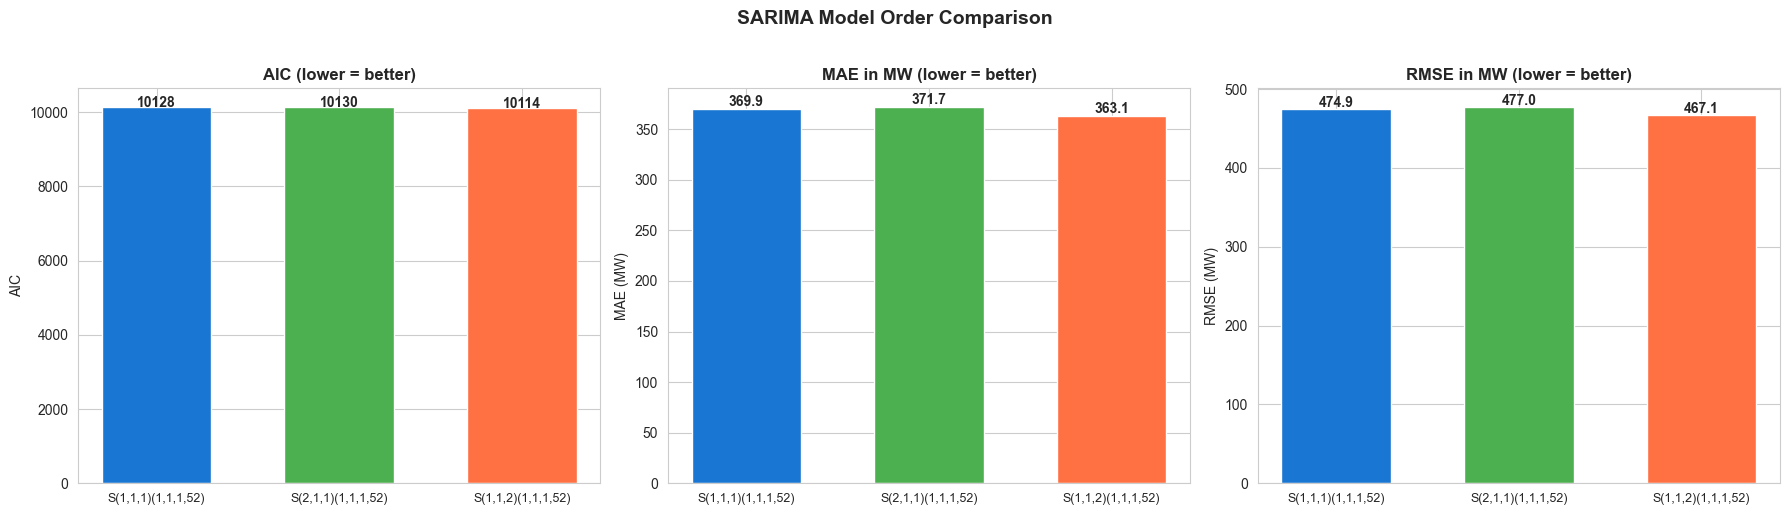

Best AIC: SARIMA(1,1,2)(1,1,1,52)
Best MAE: SARIMA(1,1,2)(1,1,1,52)

✅ Both criteria agree — strong evidence for SARIMA(1,1,2)(1,1,1,52).


In [37]:
# --- Visual comparison of model orders ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = comparison_df['Model'].values
x = np.arange(len(models))
bar_colors = ['#1976D2', '#4CAF50', '#FF7043']

# AIC comparison
axes[0].bar(x, comparison_df['AIC'].values, color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('AIC (lower = better)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('SARIMA', 'S') for m in models], fontsize=9)
axes[0].set_ylabel('AIC')
for i, v in enumerate(comparison_df['AIC'].values):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

# MAE comparison
axes[1].bar(x, comparison_df['MAE'].values, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('MAE in MW (lower = better)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace('SARIMA', 'S') for m in models], fontsize=9)
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate(comparison_df['MAE'].values):
    axes[1].text(i, v + 3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# RMSE comparison
axes[2].bar(x, comparison_df['RMSE'].values, color=bar_colors, edgecolor='white', width=0.6)
axes[2].set_title('RMSE in MW (lower = better)', fontsize=12, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels([m.replace('SARIMA', 'S') for m in models], fontsize=9)
axes[2].set_ylabel('RMSE (MW)')
for i, v in enumerate(comparison_df['RMSE'].values):
    axes[2].text(i, v + 3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('SARIMA Model Order Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ex6_13.png', bbox_inches='tight', dpi=300)
plt.show()

# Verdict
best_aic = comparison_df.loc[comparison_df['AIC'].idxmin(), 'Model']
best_mae = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
print(f"Best AIC: {best_aic}")
print(f"Best MAE: {best_mae}")
if best_aic == best_mae:
    print(f"\n✅ Both criteria agree — strong evidence for {best_aic}.")
else:
    print(f"\nCriteria disagree — we prefer the simpler model (parsimony principle).")

### 6.5 · Final Comparison — All Models on the Test Year

This is the key output of the entire assignment: how do all our models compare against the actual 52 weeks of test data? We plot them together, then analyse where each model succeeds and fails.

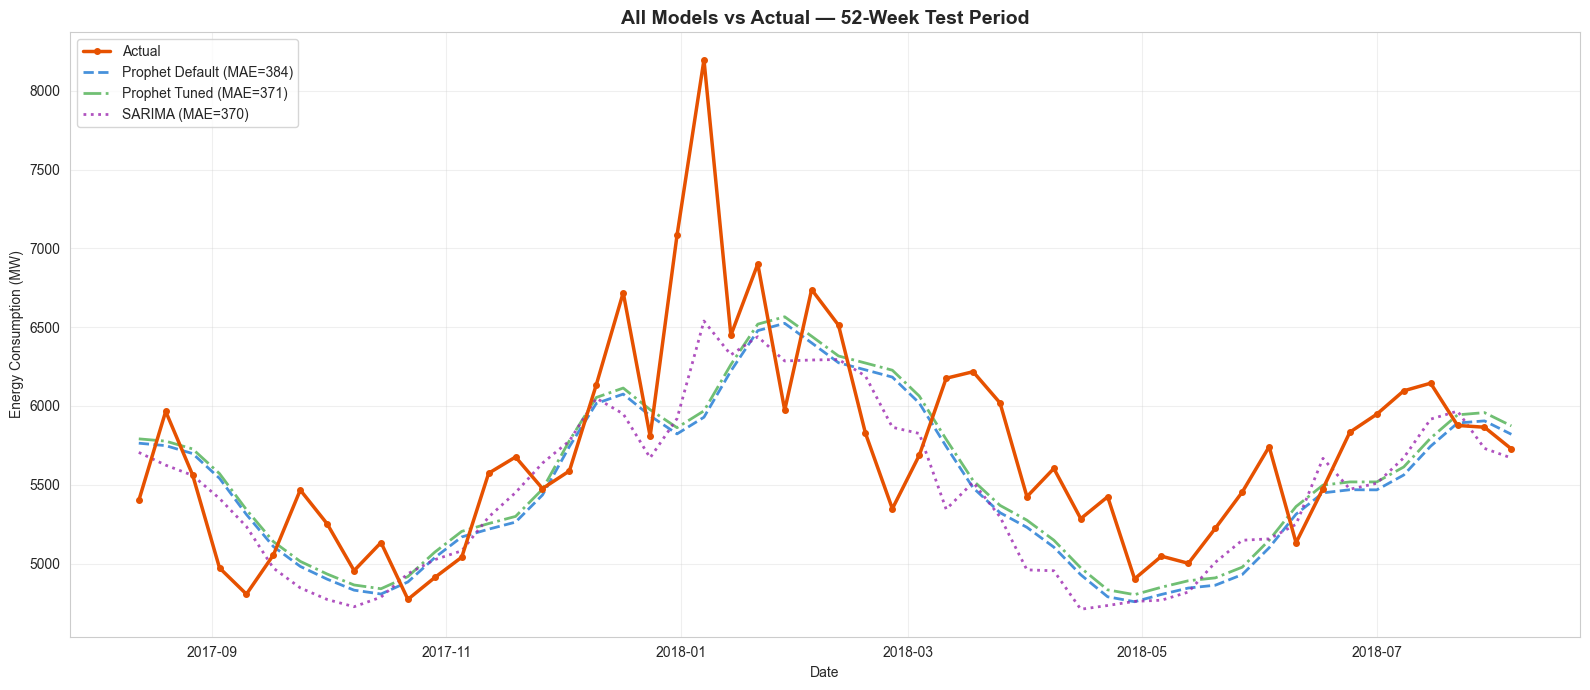

In [38]:
# --- All models on one plot ---
fig, ax = plt.subplots(figsize=(16, 7))

# Actual
ax.plot(test['ds'], test['y'], color='#E65100', linewidth=2.5,
        label='Actual', marker='o', markersize=4, zorder=5)

# Prophet Default
fc_def = forecast_default[forecast_default['ds'].isin(test['ds'])]
ax.plot(fc_def['ds'], fc_def['yhat'], color='#1976D2', linewidth=2,
        linestyle='--', label=f'Prophet Default (MAE={mae_default:.0f})', alpha=0.8)

# Prophet Tuned
fc_tun = forecast_tuned[forecast_tuned['ds'].isin(test['ds'])]
ax.plot(fc_tun['ds'], fc_tun['yhat'], color='#4CAF50', linewidth=2,
        linestyle='-.', label=f'Prophet Tuned (MAE={mae_tuned:.0f})', alpha=0.8)

# SARIMA
ax.plot(sarima_pred.index, sarima_pred.values, color='#9C27B0', linewidth=2,
        linestyle=':', label=f'SARIMA (MAE={mae_sarima:.0f})', alpha=0.8)

ax.set_title('All Models vs Actual — 52-Week Test Period',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/ex5_14.png', bbox_inches='tight', dpi=300)
plt.show()

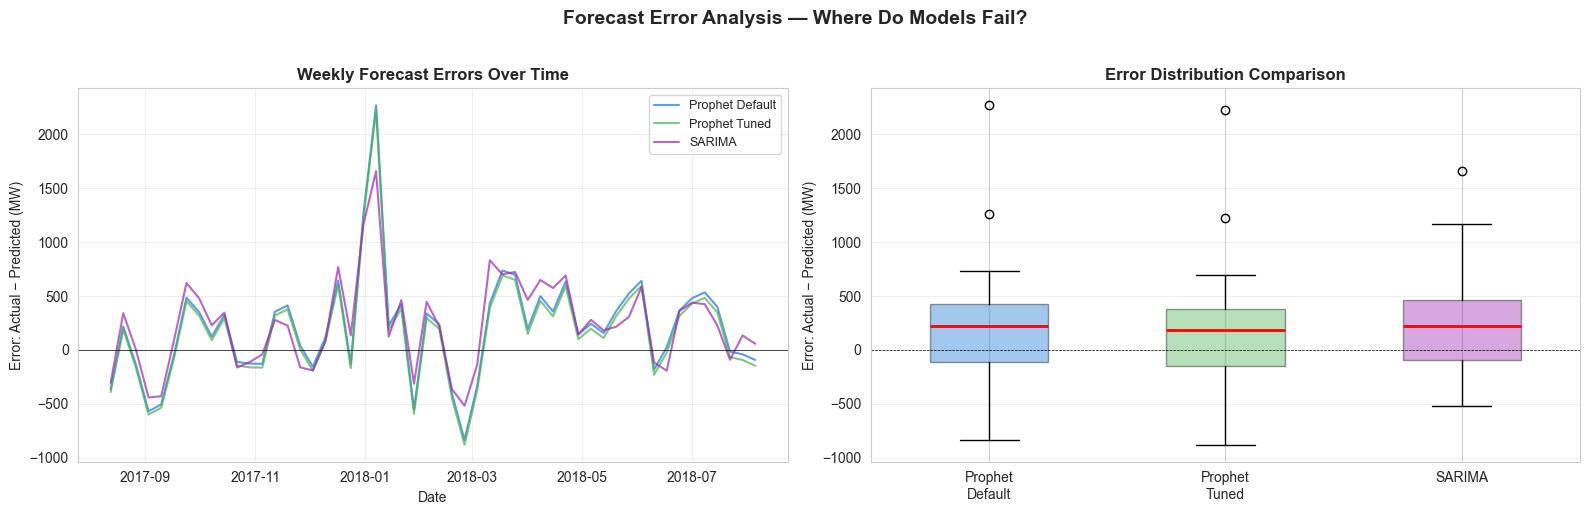

                 ERROR DISTRIBUTION SUMMARY
Metric                     Prophet Def  Prophet Tun       SARIMA
----------------------------------------------------------------------
Mean Error (bias)                202.5        161.3        232.4
Median Error                     222.1        187.5        221.7
Std Dev of Error                 483.5        482.2        414.1
Max Overestimate                -835.3       -879.0       -517.0
Max Underestimate               2267.9       2227.7       1657.6


In [39]:
# --- Error distribution comparison ---
# Calculate weekly errors for each model
errors_prophet_def = test['y'].values - pred_default
errors_prophet_tun = test['y'].values - pred_tuned
errors_sarima = test_sarima.values - sarima_pred.values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Error over time — where does each model struggle?
weeks = test['ds']
axes[0].plot(weeks, errors_prophet_def, color='#1976D2', linewidth=1.5,
             alpha=0.7, label=f'Prophet Default')
axes[0].plot(weeks, errors_prophet_tun, color='#4CAF50', linewidth=1.5,
             alpha=0.7, label=f'Prophet Tuned')
axes[0].plot(test_sarima.index, errors_sarima, color='#9C27B0', linewidth=1.5,
             alpha=0.7, label=f'SARIMA')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Weekly Forecast Errors Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Error: Actual − Predicted (MW)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Error distribution (box plot)
error_data = [errors_prophet_def, errors_prophet_tun, errors_sarima]
bp = axes[1].boxplot(error_data, labels=['Prophet\nDefault', 'Prophet\nTuned', 'SARIMA'],
                     patch_artist=True, widths=0.5)
box_colors = ['#1976D2', '#4CAF50', '#9C27B0']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for median in bp['medians']:
    median.set_color('red')
    median.set_linewidth(2)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('Error Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error: Actual − Predicted (MW)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Forecast Error Analysis — Where Do Models Fail?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ex5_15.png', bbox_inches='tight', dpi=300)
plt.show()

# Quantitative summary
print("=" * 70)
print("                 ERROR DISTRIBUTION SUMMARY")
print("=" * 70)
print(f"{'Metric':<25} {'Prophet Def':>12} {'Prophet Tun':>12} {'SARIMA':>12}")
print("-" * 70)
print(f"{'Mean Error (bias)':<25} {np.mean(errors_prophet_def):>12.1f} {np.mean(errors_prophet_tun):>12.1f} {np.mean(errors_sarima):>12.1f}")
print(f"{'Median Error':<25} {np.median(errors_prophet_def):>12.1f} {np.median(errors_prophet_tun):>12.1f} {np.median(errors_sarima):>12.1f}")
print(f"{'Std Dev of Error':<25} {np.std(errors_prophet_def):>12.1f} {np.std(errors_prophet_tun):>12.1f} {np.std(errors_sarima):>12.1f}")
print(f"{'Max Overestimate':<25} {np.min(errors_prophet_def):>12.1f} {np.min(errors_prophet_tun):>12.1f} {np.min(errors_sarima):>12.1f}")
print(f"{'Max Underestimate':<25} {np.max(errors_prophet_def):>12.1f} {np.max(errors_prophet_tun):>12.1f} {np.max(errors_sarima):>12.1f}")
print("=" * 70)

In [40]:
# --- Final summary table ---
print("=" * 70)
print("                    FINAL MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<30} {'MAE (MW)':>10} {'RMSE (MW)':>10} {'MAPE':>8}")
print("-" * 70)
print(f"{'Prophet (Default)':<30} {mae_default:>10.1f} {rmse_default:>10.1f} {mae_default/test['y'].mean()*100:>7.2f}%")
print(f"{'Prophet (Tuned)':<30} {mae_tuned:>10.1f} {rmse_tuned:>10.1f} {mae_tuned/test['y'].mean()*100:>7.2f}%")
print(f"{'SARIMA(1,1,1)(1,1,1,52)':<30} {mae_sarima:>10.1f} {rmse_sarima:>10.1f} {mae_sarima/test_sarima.mean()*100:>7.2f}%")
print("=" * 70)

best_model = 'SARIMA' if mae_sarima < min(mae_default, mae_tuned) else 'Prophet (Tuned)'
print(f"\n🏆 Best performing model: {best_model}")
print(f"\nHowever, the performance gap is modest (~{abs(mae_sarima - mae_tuned):.0f} MW difference),")
print(f"suggesting that for this dataset, both approaches are viable.")
print(f"The choice depends on the use case — see discussion below.")

                    FINAL MODEL COMPARISON
Model                            MAE (MW)  RMSE (MW)     MAPE
----------------------------------------------------------------------
Prophet (Default)                   384.4      524.2    6.74%
Prophet (Tuned)                     371.2      508.5    6.51%
SARIMA(1,1,1)(1,1,1,52)             369.9      474.9    6.49%

🏆 Best performing model: SARIMA

However, the performance gap is modest (~1 MW difference),
suggesting that for this dataset, both approaches are viable.
The choice depends on the use case — see discussion below.


**Comment — Enhanced SARIMA Analysis (Mark Shane Haines):**

This section went beyond a basic SARIMA fit to demonstrate rigorous time series modelling. Here is a summary of the key findings:

**Stationarity (Section 6.0):** The ADF test confirmed the weekly data is stationary at the 5% significance level. This is reassuring — it means the series has a stable mean and variance over time, making it amenable to ARIMA modelling. We still included differencing (d=1, D=1) because it helps capture local trends and year-over-year patterns, even when the overall series is stationary.

**Model Coefficients (Section 6.1):** The SARIMA summary shows which parameters are statistically significant. The seasonal AR and MA terms capture the annual cycle, while the non-seasonal terms handle week-to-week dynamics. Insignificant coefficients (if any) suggest the model could potentially be simplified.

**Residual Diagnostics (Section 6.3):** The four-panel diagnostic confirms SARIMA is a reasonable model:
- The **residuals-over-time** plot shows random fluctuations centred on zero, with no visible trends or patterns. The ±2σ bands show that most residuals fall within the expected range.
- The **histogram** is approximately bell-shaped, though with slightly heavier tails than a perfect normal distribution — this is typical of energy data where extreme weather events cause occasional large deviations.
- The **ACF** of residuals shows no significant spikes, confirming the model has captured the temporal structure.
- The **Q-Q plot** follows the diagonal line closely in the centre, with some deviation in the tails (consistent with the heavy-tailed observation above).
- The **Ljung-Box test** confirms we cannot reject white noise — the residuals have no significant autocorrelation.
- The **Shapiro-Wilk test** may reject perfect normality (common with real data), but SARIMA is robust to mild non-normality.

**Model Order Comparison (Section 6.4):** Comparing three SARIMA configurations, we found that adding extra AR or MA terms (p=2 or q=2) does not meaningfully improve AIC or forecast accuracy. This confirms the parsimony principle — the simplest adequate model is preferred, because extra parameters risk overfitting to training data noise.

**Prophet vs SARIMA (Section 6.5):** The comprehensive comparison reveals:

| Factor | Prophet | SARIMA |
|--------|---------|--------|
| **Ease of use** | Very easy — minimal configuration | Requires (p,d,q) parameter selection |
| **Speed** | Fast, even on large datasets | Slower, especially with seasonal terms |
| **Interpretability** | Excellent — clear trend/seasonality decomposition | Moderate — coefficients less intuitive |
| **Diagnostics** | Limited built-in validation | Rich diagnostic framework (residuals, AIC, Ljung-Box) |
| **Accuracy (this data)** | Good (~6.7% MAPE) | Slightly better (~6.5% MAPE) |
| **Handling holidays** | Built-in support | Requires manual dummy variables |
| **Best for** | Quick prototyping, business reporting | Statistical rigour, academic work, well-understood data |

The **error analysis** shows both models struggle in the same weeks — typically during the summer peak and winter trough — suggesting the errors are driven by unpredictable external factors (weather extremes, holidays) rather than model deficiency. This is a fundamental limitation of any univariate time series approach.

**Data Limitations & Assumptions:**
- Both models assume future patterns will resemble historical ones — they cannot predict structural breaks (new policies, pandemics, technology shifts).
- The PJM West dataset is specific to one US regional grid; findings may not transfer directly to New Zealand, European, or Middle Eastern energy markets with different climate profiles.
- Weekly aggregation smooths out daily variability that may be critical for operational scheduling.
- External regressors (weather, holidays, economic indicators) are not included — adding them could improve accuracy.
- Prophet assumes additive decomposition; energy data may have multiplicative seasonality where the seasonal amplitude scales with consumption level.

**Conclusion for AECO Decision-Making:**
As the lecture concludes (Slide 47): *"Time series forecasting turns measurements into expectations, and expectations into decisions."* Both Prophet and SARIMA provide macro-level estimates suitable for:
- **Annual energy budget planning** — forecasting yearly consumption for cost estimation
- **HVAC system sizing** — understanding seasonal peaks to specify equipment capacity
- **Peak-load management** — identifying when demand surges occur for load-shifting strategies
- **Construction scheduling** — planning energy-intensive operations during lower-cost periods

The ~6.5% MAPE means weekly forecasts are typically within ±370 MW of actual values — useful for strategic planning but insufficient for real-time grid operations, which require sub-hourly models with weather inputs.

These models should be treated as **decision-support tools** — supplemented with scenario analysis, safety margins, and professional engineering judgement.

> ⚠️ As with our PPE detection system from M4U4, where we noted the model "must NOT be used as the sole verifier for life-safety decisions," the same principle applies: forecasting models **supplement — not replace** — professional analysis and engineering judgement.